# Workshop 1 — EDA con NumPy y Pandas: Airbnb Listings

**Integrantes:**
- `Kevin Pabon` — Fases 1 y 2
- `Jose Alejandro Jimenez` — Fase 3
- `Geronimo Montes Acebedo` — Fase 4 y 5

**Dataset:** Airbnb Listings ([Kaggle](https://www.kaggle.com/datasets/ulrikthygepedersen/airbnb-listings))

**Archivo fuente:** `data/airbnb/Listings.csv`



## Punto 1 — Descripción del tema del dataset

El dataset tiene **279,712 listados de Airbnb** en **10 ciudades** (París, Nueva York, Bangkok, Río de Janeiro, Sídney, Estambul, Roma, Hong Kong, Ciudad de México y Ciudad del Cabo).

Cada fila es un listado y trae info del **host** (antigüedad, ubicación, tiempo de respuesta, si es superhost), de la **propiedad** (barrio, ciudad, coordenadas, tipo, capacidad, amenities), las **condiciones de reserva** (precio, noches mín/máx, reserva instantánea) y las **reseñas** (rating general + 6 sub-puntajes).

Es una foto en un momento dado, no un histórico: no hay columna de fecha de scraping (`host_since` es cuándo se registró el host, no cuándo se capturó el dato), Kaggle marca `expectedUpdateFrequency: never`, y no hay `listing_id` repetidos.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_PATH = "data/airbnb/Listings.csv"

# El CSV es UTF-8 valido en casi la totalidad de sus filas, pero tiene un puñado
# de bytes corruptos de origen (ej. un caracter mal guardado en un nombre de barrio).
# encoding_errors="replace" sustituye SOLO esos bytes puntuales por el caracter de
# reemplazo U+FFFD, sin degradar el resto del archivo (a diferencia de forzar
# encoding="latin-1" para todo el archivo, que rompe el texto UTF-8 que si es valido).
df = pd.read_csv(DATA_PATH, encoding="utf-8", encoding_errors="replace", low_memory=False)

print("Shape inicial:", df.shape)


Shape inicial: (279712, 33)


## Punto 2 — head() y tail()

Primeras y últimas 5 filas, tal cual vienen del CSV (todavía sin limpiar).

In [2]:
print("HEAD(5):")
display(df.head(5))

print("\nTAIL(5):")
display(df.tail(5))


HEAD(5):


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÂ² Paris (Sacre CÅ“ur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f



TAIL(5):


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
279707,38338635,Appartement T2 neuf prÃ¨s du tram T3a Porte Didot,31161181,2015-04-13,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Observatoire,NaN,Paris,48.82701,2.31419,Entire apartment,Entire place,2,1.0,"[""Iron"", ""Heating"", ""Washer"", ""Dedicated works...",120,1,7,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279708,38538692,Cozy Studio in Montmartre,10294858,2013-11-27,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.89309,2.33206,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Iron"", ""Heating"", ""Washer"", ""Hair...",60,7,15,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279709,38683356,Nice and cosy mini-appartement in Paris,2238502,2012-04-27,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88699,2.34920,Entire apartment,Entire place,2,1.0,"[""Paid parking off premises"", ""Shampoo"", ""Firs...",50,6,30,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279710,39659000,Charming apartment near Rue Saint Maur / Oberk...,38633695,2015-07-16,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Popincourt,NaN,Paris,48.86687,2.38123,Entire apartment,Entire place,2,1.0,"[""TV"", ""Iron"", ""Kitchen"", ""Hangers"", ""Smoke al...",105,3,18,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279711,40219504,Cosy apartment with view on Canal St Martin,6955618,2013-06-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Enclos-St-Laurent,NaN,Paris,48.87217,2.36320,Entire apartment,Entire place,2,1.0,"[""Shower gel"", ""Shampoo"", ""Iron"", ""Heating"", ""...",70,2,4,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


## Punto 3 — .shape y diccionario de datos

El dataset tiene **279,712 filas × 33 columnas**. Diccionario de datos:

| Columna | Tipo esperado | Significado |
|---|---|---|
| listing_id | numérica (entero, ID) | Identificador único del listado |
| name | categórica (texto libre) | Título/nombre del anuncio |
| host_id | numérica (entero, ID) | Identificador único del host |
| host_since | fecha | Fecha en que el host se registró en Airbnb |
| host_location | categórica (texto libre) | Ciudad/país declarado por el host |
| host_response_time | categórica | Rapidez típica de respuesta del host |
| host_response_rate | numérica (%) | % de mensajes que el host responde |
| host_acceptance_rate | numérica (%) | % de solicitudes de reserva que el host acepta |
| host_is_superhost | categórica (booleana f/t) | Si el host tiene estatus "superhost" |
| host_total_listings_count | numérica (entero) | Cantidad total de propiedades que administra el host |
| host_has_profile_pic | categórica (booleana f/t) | Si el host tiene foto de perfil |
| host_identity_verified | categórica (booleana f/t) | Si Airbnb verificó la identidad del host |
| neighbourhood | categórica | Barrio dentro de la ciudad |
| district | categórica | Distrito (solo poblado para Nueva York) |
| city | categórica | Ciudad del listado (10 valores posibles) |
| latitude | numérica (continua) | Latitud geográfica |
| longitude | numérica (continua) | Longitud geográfica |
| property_type | categórica | Tipo de propiedad (apartamento, casa, loft, etc.) |
| room_type | categórica | Tipo de habitación ofrecida (lugar completo, privada, compartida, hotel) |
| accommodates | numérica (entero) | Capacidad máxima de huéspedes |
| bedrooms | numérica (entero, con nulos) | Número de habitaciones |
| amenities | categórica (texto tipo lista) | Lista de comodidades ofrecidas, en formato string JSON |
| price | numérica (entero) | Precio por noche, **en moneda local de cada ciudad** |
| minimum_nights | numérica (entero) | Noches mínimas exigidas por reserva |
| maximum_nights | numérica (entero) | Noches máximas permitidas por reserva |
| review_scores_rating | numérica (0-100) | Puntaje general de reseñas |
| review_scores_accuracy | numérica (0-10) | Puntaje de precisión de la descripción |
| review_scores_cleanliness | numérica (0-10) | Puntaje de limpieza |
| review_scores_checkin | numérica (0-10) | Puntaje del proceso de check-in |
| review_scores_communication | numérica (0-10) | Puntaje de comunicación con el host |
| review_scores_location | numérica (0-10) | Puntaje de ubicación |
| review_scores_value | numérica (0-10) | Puntaje de relación calidad-precio |
| instant_bookable | categórica (booleana f/t) | Si el listado permite reserva instantánea sin aprobación |

**Nota sobre escalas de reseñas:** ojo que `review_scores_rating` va de **0 a 100** y las 6 sub-métricas van de **0 a 10** — no son comparables directamente sin normalizar (verificado con `.describe()`, el rating va de 20 a 100).

In [3]:
print("Shape:", df.shape)
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("\nNombres de columnas:")
print(list(df.columns))


Shape: (279712, 33)
Filas: 279712
Columnas: 33

Nombres de columnas:
['listing_id', 'name', 'host_id', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'district', 'city', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable']


## Punto 4 — .info() y .dtypes

**Numéricas:** `listing_id`, `host_id`, `host_response_rate`, `host_acceptance_rate`, `host_total_listings_count`, `latitude`, `longitude`, `accommodates`, `bedrooms`, `price`, `minimum_nights`, `maximum_nights`, `review_scores_rating` y sus 6 sub-métricas.

**Categóricas:** `name`, `host_location`, `host_response_time`, `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `neighbourhood`, `district`, `city`, `property_type`, `room_type`, `amenities`, `instant_bookable`.

**Fecha:** `host_since` debería ser fecha pero pandas la carga como `object` porque el CSV no trae tipo nativo. Se convierte de verdad en el Punto 10.

In [4]:
df.info()
print("\nDtypes:")
print(df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

## Punto 5 — .describe() e interpretación

- **`price`**: la media mezcla 10 monedas distintas (medianas van de 65 en Roma a 1100 en Bangkok), así que **la media/std global no significa nada real** — solo sirve calculada por ciudad (Punto 6).
- **`accommodates`**: mediana de 2 huéspedes, tiene sentido porque la mayoría son apartamentos completos o privados pensados para parejas o viajeros solos.
- **`review_scores_rating`** (escala 0-100, distinta a las sub-métricas de 0-10): muy sesgada hacia arriba — media 93.4, mediana 96, Q1 91. Que el 75% califique sobre 91 significa que un rating "bueno" casi no distingue nada; lo que importa es caer por debajo de ~90. Es el típico sesgo positivo de las plataformas de hospedaje.
- **`maximum_nights`**: la media (~27,558) dispara respecto a la mediana (1125) por placeholders como `2147483647` que significan "sin límite", no una noche máxima real.

Los placeholders se dejan crudos acá a propósito — es el reconocimiento inicial, antes de limpiar nada. Se tratan en el Punto 11.

In [5]:
display(df.describe())


,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2.797120e+05,2.797120e+05,150930.000000,166625.000000,279547.000000,279712.000000,279712.000000,279712.000000,250277.000000,279712.000000,279712.000000,2.797120e+05,188307.000000,187999.000000,188047.000000,187941.000000,188025.000000,187937.000000,187927.000000
mean,2.638196e+07,1.081658e+08,0.865939,0.827168,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,2.755860e+04,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
std,1.442576e+07,1.108570e+08,0.283744,0.289202,284.041143,32.560343,73.081309,2.133379,1.153080,3441.826611,31.518946,7.282875e+06,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
min,2.577000e+03,1.822000e+03,0.000000,0.000000,0.000000,-34.264400,-99.339630,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.384462e+07,1.720656e+07,0.900000,0.780000,1.000000,-22.964390,-43.198040,2.000000,1.000000,75.000000,1.000000,4.500000e+01,91.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,2.767098e+07,5.826911e+07,1.000000,0.980000,1.000000,40.710785,2.382780,2.000000,1.000000,150.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.978485e+07,1.832853e+08,1.000000,1.000000,4.000000,41.908610,28.986730,4.000000,2.000000,474.000000,5.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.834353e+07,3.901874e+08,1.000000,1.000000,7235.000000,48.904910,151.339810,16.000000,50.000000,625216.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


## Punto 6 — Conversión a NumPy: media, mediana y std de `price`

Como `price` está en moneda local por ciudad, calcular media/mediana/std sobre las 279,712 filas mezclaría monedas sin sentido. Por eso se filtra a **una sola ciudad: París** (la que más registros tiene, 64,690).

In [6]:
city_top = df["city"].value_counts().idxmax()
print("Ciudad con mas registros:", city_top, "->", df["city"].value_counts().max(), "listados")

price_city_np = df.loc[df["city"] == city_top, "price"].to_numpy()

media_np = np.mean(price_city_np)
mediana_np = np.median(price_city_np)
std_np = np.std(price_city_np)          # ddof=0 (poblacional), default de NumPy
std_np_ddof1 = np.std(price_city_np, ddof=1)  # ddof=1 (muestral), para comparar con pandas

print(f"\nNumPy (price en {city_top}, n={len(price_city_np)}):")
print(f"  media   = {media_np:.2f}")
print(f"  mediana = {mediana_np:.2f}")
print(f"  std (ddof=0, poblacional) = {std_np:.2f}")
print(f"  std (ddof=1, muestral)    = {std_np_ddof1:.2f}")

desc_city = df.loc[df["city"] == city_top, "price"].describe()
print(f"\n.describe() de price en {city_top}:")
print(desc_city)


Ciudad con mas registros: Paris -> 64690 listados



NumPy (price en Paris, n=64690):
  media   = 113.10
  mediana = 80.00
  std (ddof=0, poblacional) = 214.43
  std (ddof=1, muestral)    = 214.43

.describe() de price en Paris:
count    64690.000000
mean       113.096445
std        214.433668
min          0.000000
25%         59.000000
50%         80.000000
75%        120.000000
max      12000.000000
Name: price, dtype: float64


**Comparación:** la media y mediana a mano con NumPy dan igual que `.describe()`. La única diferencia es la **std**: `np.std()` usa `ddof=0` (población) y pandas usa `ddof=1` (muestra) — por eso se calculó también con `ddof=1`, que sí coincide. Con n=64,690 la diferencia es mínima, pero conviene saber qué usa cada herramienta por defecto.

## Punto 7 — Nulos por columna (conteo y %)

Conteo y % de nulos sobre el total (279,712), solo para las columnas que tienen al menos uno.

In [7]:
nulls = df.isnull().sum()
pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({"nulos": nulls, "pct_%": pct})
null_report = null_report[null_report["nulos"] > 0].sort_values("nulos", ascending=False)
display(null_report)

print("\nColumnas sin nulos:")
print(list(df.columns[df.isnull().sum() == 0]))


,nulos,pct_%
district,242700,86.77
host_response_time,128782,46.04
host_response_rate,128782,46.04
host_acceptance_rate,113087,40.43
review_scores_value,91785,32.81
review_scores_location,91775,32.81
review_scores_checkin,91771,32.81
review_scores_accuracy,91713,32.79
review_scores_communication,91687,32.78
review_scores_cleanliness,91665,32.77



Columnas sin nulos:


['listing_id', 'host_id', 'neighbourhood', 'city', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'instant_bookable']


## Punto 8 — Estrategia de nulos justificada por columna

**Regla del taller: no se elimina ninguna columna completa**, ni `district` con 86.77% de nulos.

Cada columna con nulos se clasifica como **estructural** (el nulo significa "no aplica") o **aleatoria** (falta de captura, se puede imputar).

### Estructurales — se dejan NaN o constante + flag, no se imputan con media/mediana/moda

| Columna | Estrategia | Por qué |
|---|---|---|
| `district` | NaN | Solo existe para Nueva York, para las otras 9 ciudades no aplica. |
| `host_response_time` | Constante `"Sin datos"` + flag | Nulo cuando el host nunca respondió mensajes, no es un error. |
| `host_response_rate` | NaN + flag | Mismos 128,782 nulos exactos que el anterior. |
| `review_scores_rating` y las 6 sub-métricas | NaN + flag `tiene_resenas` | Nulo = listado sin reseñas todavía. Imputar escondería que es nuevo. Nota: rating nulo en 91,405 filas, las 7 juntas en 91,377, y al menos una en 91,881 — el patrón es *casi* estructural, no perfecto, así que se deja documentado. |

### Aleatorios — se imputan o se elimina fila

| Columna | % nulos | Estrategia | Por qué |
|---|---|---|---|
| `bedrooms` | 10.52% | Mediana | Numérica y sesgada, la mediana aguanta mejor el sesgo que la media. |
| `host_location` | 0.30% (840 filas) | NaN, no se elimina nada | Texto libre del host, imputarlo sería inventar un dato. |
| `name` | 0.06% | NaN | Texto libre, inventar un nombre no aporta nada. |
| `host_since`, `host_identity_verified`, `host_has_profile_pic`, `host_total_listings_count`, `host_is_superhost` | 0.06% c/u | Eliminar filas | Son exactamente las mismas 165 filas (ver abajo). |

### Por qué se eliminan esas 165 filas

Los nulos de esas columnas de metadata de host caen **en las mismas 165 filas** (verificado). Parece un bloque de cuentas eliminadas de la plataforma. El `dropna` sobre ese subconjunto borra exactamente 165 filas, ni una más — el volumen es despreciable (0.06%) y una fila sin metadata de host aporta poco.

### `host_location` es aparte

Tiene 840 nulos propios, no los mismos 165. Las ~675 filas con `host_location` nulo pero metadata de host completa **sobreviven** a la limpieza con su NaN intacto.

In [8]:
df_clean = df.copy()

# --- Estructurales: flags + constante/NaN, SIN imputar con media/mediana/moda ---
df_clean["tiene_resenas"] = df_clean["review_scores_rating"].notna()
df_clean["tiene_respuesta_host"] = df_clean["host_response_time"].notna()

df_clean["host_response_time"] = df_clean["host_response_time"].fillna("Sin datos")
# host_response_rate, review_scores_* y district se dejan en NaN (estructural, no se imputan)

# --- Aleatorios ---
mediana_bedrooms = df_clean["bedrooms"].median()
df_clean["bedrooms"] = df_clean["bedrooms"].fillna(mediana_bedrooms)
print(f"bedrooms: nulos imputados con mediana = {mediana_bedrooms}")

# PRUEBA: los nulos de metadata de host estan en las MISMAS filas
cols_bloque_host = ["host_since", "host_is_superhost", "host_has_profile_pic",
                    "host_identity_verified"]
print("\nNulos por columna del bloque de metadata de host:")
print(df[cols_bloque_host].isnull().sum())
n_bloque = df[cols_bloque_host].isnull().all(axis=1).sum()
print(f"\nFilas con las 4 columnas nulas SIMULTANEAMENTE: {n_bloque}")
print("-> Coincide con los 165 nulos de cada columna: son las mismas 165 filas.")

# host_location NO pertenece a ese bloque: tiene sus propios nulos, mas numerosos
print(f"\nhost_location nulos: {df['host_location'].isnull().sum()} (NO son las mismas 165 filas)")
solo_host_location = (df["host_location"].isnull() & df[cols_bloque_host].notna().all(axis=1)).sum()
print(f"Filas con host_location nulo pero metadata de host completa: {solo_host_location}")
print("-> Esas filas sobreviven a la limpieza y conservan su NaN en host_location.")

filas_antes = len(df_clean)
cols_host_meta = ["host_since", "host_identity_verified", "host_has_profile_pic",
                   "host_total_listings_count", "host_is_superhost"]
df_clean = df_clean.dropna(subset=cols_host_meta)
print(f"\nFilas eliminadas por metadata de host incompleta: {filas_antes - len(df_clean)}")

# host_location y name: se dejan como estan (NaN), no se imputan ni se eliminan filas
print(f"host_location nulos que sobreviven en df_clean: {df_clean['host_location'].isnull().sum()}")

print("\nVerificacion post-limpieza (isnull().sum()):")
print(df_clean.isnull().sum())


bedrooms: nulos imputados con mediana = 1.0

Nulos por columna del bloque de metadata de host:


host_since                165
host_is_superhost         165
host_has_profile_pic      165
host_identity_verified    165
dtype: int64

Filas con las 4 columnas nulas SIMULTANEAMENTE: 165
-> Coincide con los 165 nulos de cada columna: son las mismas 165 filas.

host_location nulos: 840 (NO son las mismas 165 filas)
Filas con host_location nulo pero metadata de host completa: 675
-> Esas filas sobreviven a la limpieza y conservan su NaN en host_location.



Filas eliminadas por metadata de host incompleta: 165
host_location nulos que sobreviven en df_clean: 675

Verificacion post-limpieza (isnull().sum()):


listing_id                          0
name                              174
host_id                             0
host_since                          0
host_location                     675
host_response_time                  0
host_response_rate             128617
host_acceptance_rate           112922
host_is_superhost                   0
host_total_listings_count           0
host_has_profile_pic                0
host_identity_verified              0
neighbourhood                       0
district                       242553
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                            0
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91348
review_score

## Punto 9 — Duplicados

Se revisan duplicados exactos de fila y duplicados lógicos por `listing_id` (que debería ser único).

In [9]:
dup_exact = df_clean.duplicated().sum()
print("Duplicados exactos de fila:", dup_exact)

if dup_exact > 0:
    df_clean = df_clean.drop_duplicates()
    print("Filas eliminadas por duplicado exacto:", dup_exact)
else:
    print("No se eliminó ninguna fila: 0 duplicados exactos encontrados.")

dup_ids = df_clean["listing_id"].duplicated().sum()
print("\nDuplicados logicos por listing_id:", dup_ids)
print("listing_id unicos:", df_clean['listing_id'].nunique(), "vs filas totales:", len(df_clean))
print("-> Cada fila corresponde a un listing_id unico, no hay duplicados logicos.")


Duplicados exactos de fila: 0
No se eliminó ninguna fila: 0 duplicados exactos encontrados.

Duplicados logicos por listing_id: 0
listing_id unicos: 279547 vs filas totales: 279547
-> Cada fila corresponde a un listing_id unico, no hay duplicados logicos.


## Punto 10 — Inconsistencias de formato en columnas de texto

Primero se chequean con `.unique()` las categóricas "cerradas" (`room_type`, `city`) — ya salían consistentes desde el reconocimiento inicial, sin mayúsculas mezcladas ni categorías repetidas escritas distinto, así que solo se confirma.

Después se corrigen tres cosas:

1. **Encoding roto (mojibake):** mucho texto quedó doblemente codificado, tipo `"PÃ¨re Lachaise"` en vez de `"Père Lachaise"`. Se arregla con `.encode("cp1252").decode("utf-8")`, pero solo si el resultado mejora de verdad (si el texto ya estaba bien, aplicar la conversión a ciegas lo rompería). Se usa `cp1252` y no `latin-1` porque el texto trae comillas tipográficas que `latin-1` no soporta.

   **Resultado:** se recupera ~98.6% del mojibake de `name` (25,697 → 449 filas residuales). De esas 449:
   - **360** son mojibake real mezclado con emojis/símbolos que `cp1252` no puede codificar — se dejan intactas por diseño, mejor no tocar que corromper. No se corrigen porque `name` no se usa en `groupby` ni en las gráficas.
   - **89** no son mojibake — es portugués legítimo de Río de Janeiro (`coraçÃO`, `MaracanÃ`), donde `Ã` es parte real de la palabra. La guarda "solo corrige si mejora" hizo bien en no tocarlas.

   Aparte, hay **5 filas con un byte corrupto de origen** (`0x81` en "Álvaro Obregón", cargadas con `encoding_errors="replace"` y marcadas con `�`). No tienen nada que ver con las 449 — es pérdida de info del archivo original, no un problema de encoding, así que solo se reportan.

2. **Booleanos como texto (`'f'`/`'t'`)** en `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `instant_bookable` → se pasan a `True`/`False` reales.

3. **`host_since` como string** → se convierte a fecha con `pd.to_datetime(errors='coerce')`. Da 0 NaT porque los 165 nulos originales ya se habían eliminado en el Punto 8.

`host_location` y `amenities` solo se reportan (`.value_counts().head(15)`) — normalizarlas de verdad se sale del alcance de esta fase.

In [10]:
# 0. Columnas categoricas cerradas: verificar con .unique() que ya son consistentes
print("room_type.unique():", df_clean["room_type"].unique())
print("\ncity.unique():", df_clean["city"].unique())
print("\n-> Ambas ya son consistentes: sin mayusculas mezcladas, espacios extra ni")
print("   categorias equivalentes escritas distinto. No requieren correccion.")

# 1. Encoding: deshacer la doble codificacion (mojibake)
MARCADORES = ("\u00c2", "\u00c3", "\u00c5")   # A-circunflejo, A-tilde, A-anillo: senales tipicas de mojibake

def _n_marcadores(s):
    return sum(s.count(m) for m in MARCADORES)

def fix_mojibake(text, max_pasadas=3):
    """Deshace capas de doble codificacion mientras el resultado mejore de forma
    estricta. Si la conversion introduce caracteres de reemplazo o no reduce los
    marcadores, se descarta y se conserva el texto original."""
    if not isinstance(text, str):
        return text
    actual = text
    for _ in range(max_pasadas):
        if not any(m in actual for m in MARCADORES):
            break
        candidato = None
        for enc in ("cp1252", "latin-1"):
            try:
                candidato = actual.encode(enc).decode("utf-8")
                break
            except (UnicodeEncodeError, UnicodeDecodeError):
                continue
        if candidato is None:
            break
        introduce_basura = "\ufffd" in candidato and "\ufffd" not in actual
        if introduce_basura or _n_marcadores(candidato) >= _n_marcadores(actual):
            break
        actual = candidato
    return actual

def _filas_con_mojibake(serie):
    """Cuenta filas DISTINTAS con al menos un marcador. Se combinan las mascaras con
    OR en vez de sumar un contains por marcador: una fila con 'Ã' y 'Â' a la vez
    debe contar una sola vez, no dos."""
    s = serie.astype(str)
    mascara = s.str.contains(MARCADORES[0], na=False)
    for m in MARCADORES[1:]:
        mascara = mascara | s.str.contains(m, na=False)
    return int(mascara.sum())

cols_texto = ["name", "host_location", "neighbourhood"]
print("\nMojibake por columna (filas afectadas) ANTES:")
for c in cols_texto:
    print(f"  {c}: {_filas_con_mojibake(df_clean[c])}")

ejemplos_antes = df_clean.loc[
    df_clean["name"].astype(str).str.contains("\u00c3", na=False), "name"
].head(3).tolist()

for c in cols_texto:
    df_clean[c] = df_clean[c].map(fix_mojibake)

print("\nMojibake por columna (filas afectadas) DESPUES:")
for c in cols_texto:
    print(f"  {c}: {_filas_con_mojibake(df_clean[c])}")

print("\nEjemplos ANTES :", ejemplos_antes)
print("Ejemplos DESPUES:", [fix_mojibake(x) for x in ejemplos_antes])

# --- Desglose de las filas residuales de 'name' ---
# Un marcador suelto NO implica mojibake: en portugues 'Ã' es letra real
# (coracao, localizacao, Maracana). Se separa mojibake real de texto legitimo.
import re
PATRON_SOSPECHOSO = re.compile(
    "[\u00c2\u00c3\u00c5][^\\sA-Za-z]"   # marcador seguido de algo que no es letra/espacio
    "|\u00e2|\u00ef\u00bf|\u00ef\u00b8|\u00e3\u201a"  # restos de emoji/simbolo mal decodificado
)

nombres = df_clean["name"].map(lambda v: v if isinstance(v, str) else "")
mask_resid = nombres.map(lambda v: any(m in v for m in MARCADORES))
residuales = nombres[mask_resid]

es_mojibake_real = residuales.map(lambda v: bool(PATRON_SOSPECHOSO.search(v)))
n_real = int(es_mojibake_real.sum())
n_legitimo = int((~es_mojibake_real).sum())

print(f"\nDesglose de las {len(residuales)} filas residuales de 'name':")
print(f"  - mojibake real NO corregido (simbolos fuera de cp1252): {n_real}")
print(f"  - texto legitimo en portugues (falso positivo del detector): {n_legitimo}")
print("\n  Ejemplos de mojibake real no corregido:")
for x in residuales[es_mojibake_real].head(4).tolist():
    print("   ", x)
print("\n  Ejemplos de texto legitimo (Ã es la letra real, NO se debe tocar):")
for x in residuales[~es_mojibake_real].head(4).tolist():
    print("   ", x)

# --- Conjunto APARTE: bytes corruptos de origen (no solapa con los residuales) ---
mask_fffd = nombres.str.contains("\ufffd", na=False)
n_irrecuperable = int(mask_fffd.sum())
solapan = int((mask_resid & mask_fffd).sum())
print(f"\nGrupo APARTE - filas con caracter irrecuperable (U+FFFD, byte 0x81 corrupto de origen): {n_irrecuperable}")
print(f"Filas que estan en AMBOS grupos: {solapan} -> son conjuntos disjuntos.")
print("Ejemplos:", nombres[mask_fffd].head(3).tolist())

# 2. Booleanos f/t -> True/False
bool_map = {"f": False, "t": True}
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]
for c in bool_cols:
    df_clean[c] = df_clean[c].map(bool_map)
print("\nDtypes tras conversion booleana:")
print(df_clean[bool_cols].dtypes)

# 3. host_since -> fecha real
antes_na = df_clean["host_since"].isnull().sum()
df_clean["host_since"] = pd.to_datetime(df_clean["host_since"], errors="coerce")
print(f"\nhost_since convertido a datetime. Nulos/NaT: {df_clean['host_since'].isnull().sum()} (antes de esta conversion: {antes_na}, ya sin nulos por la limpieza del Punto 8)")

# 4. Reporte de host_location y amenities SIN normalizar (fuera de alcance)
print("\nhost_location - top 15 valores mas frecuentes (inconsistencias: mezcla 'Ciudad, Region, Pais' con codigos ISO):")
print(df_clean["host_location"].value_counts().head(15))

print("\namenities - top 15 combinaciones mas frecuentes (formato string tipo lista, sin normalizar):")
print(df_clean["amenities"].value_counts().head(15))


room_type.unique(): ['Entire place' 'Private room' 'Hotel room' 'Shared room']

city.unique(): ['Paris' 'New York' 'Bangkok' 'Rio de Janeiro' 'Sydney' 'Istanbul' 'Rome'
 'Hong Kong' 'Mexico City' 'Cape Town']

-> Ambas ya son consistentes: sin mayusculas mezcladas, espacios extra ni
   categorias equivalentes escritas distinto. No requieren correccion.

Mojibake por columna (filas afectadas) ANTES:


  name: 24206


  host_location: 2788


  neighbourhood: 0



Mojibake por columna (filas afectadas) DESPUES:
  name: 449


  host_location: 4
  neighbourhood: 0

Ejemplos ANTES : ['57sqm btw. Bastille & PÃ¨re Lachaise', 'Beau 2piÃ¨ces prÃ¨s Butte aux cailles', 'Grand 2 piÃ¨ces de 60 m2 cosy au canal Saint Martin']
Ejemplos DESPUES: ['57sqm btw. Bastille & Père Lachaise', 'Beau 2pièces près Butte aux cailles', 'Grand 2 pièces de 60 m2 cosy au canal Saint Martin']



Desglose de las 449 filas residuales de 'name':
  - mojibake real NO corregido (simbolos fuera de cp1252): 356
  - texto legitimo en portugues (falso positivo del detector): 93

  Ejemplos de mojibake real no corregido:
    ã‚ˆã†ã“ã-GrÃ¼ezi-Bienvenue-Welcome Paris Le Marais
    Romantique Appartement Matignon Ã‰lysees â¤
    â˜€ï¸ Magnifique studio Paris 16Ã¨me
    â¤ï¸  AMAZING - 6 guests near to Champs-Ã‰lyseesâ¤ï¸

  Ejemplos de texto legitimo (Ã es la letra real, NO se debe tocar):
    Alugo Ap para CARNAVAL !!!! Ótima LOCALIZAÇÃO !
    APTO EM EXCELENTE LOCALIZAÇÃO
    CHARMOSO NO CORAÇÃO DO PROJAC
    ÓTIMA LOCALIZAÇÃO, AP JACAREPAGUa- RIO DE JANEIRO

Grupo APARTE - filas con caracter irrecuperable (U+FFFD, byte 0x81 corrupto de origen): 5
Filas que estan en AMBOS grupos: 0 -> son conjuntos disjuntos.
Ejemplos: ['Newly Renovated apt in front of A�lvaro Obregon!!', 'Departamento completo en A�lvaro Obregon.', 'A�lvaro Obregon/ Roma cozy Great location 3']

Dtypes tras c

amenities
["Long term stays allowed"]                                                                                                                                                                                                               1385
["Long term stays allowed", "Iron", "Air conditioning", "Wifi", "Kitchen"]                                                                                                                                                                 376
[]                                                                                                                                                                                                                                         123
["Heating", "Kitchen", "Essentials", "Washer", "Wifi", "Long term stays allowed"]                                                                                                                                                           99
["Heating", "TV", "Kitchen", "Esse

## Punto 11 — Outliers por IQR (a mano) y basura no estadística

**Nada se elimina acá**, solo se reporta.

### 11.1 — Outliers de `price` en París (misma ciudad del Punto 6)

Cálculo manual: Q1, Q3, IQR = Q3-Q1, límites = Q1 - 1.5×IQR y Q3 + 1.5×IQR.

### 11.2 — Basura no estadística (valores inválidos, no outliers de verdad)

- `minimum_nights == 9999`: absurdo, prácticamente no reservable.
- `minimum_nights >= 365`: **no es basura**, puede ser alquiler de largo plazo.
- `maximum_nights`: placeholders de "sin límite" (`1125` y `2147483647`), no son outliers reales.
- `accommodates == 0` y `price == 0`: datos inválidos, no alojamientos reales.

Estos registros quedan disponibles en `df_clean` sin filtrar — que cada gráfico de Fase 4/5 decida si los excluye, dejándolo anotado.

In [11]:
# --- 11.1 IQR sobre price en la ciudad filtrada (Punto 6) ---
price_city = df_clean.loc[df_clean["city"] == city_top, "price"]

Q1 = price_city.quantile(0.25)
Q3 = price_city.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

print(f"IQR de price en {city_top}:")
print(f"  Q1            = {Q1}")
print(f"  Q3            = {Q3}")
print(f"  IQR           = {IQR}")
print(f"  limite_inf    = {limite_inf}")
print(f"  limite_sup    = {limite_sup}")

outliers_price = price_city[(price_city < limite_inf) | (price_city > limite_sup)]
print(f"\nRegistros fuera de rango: {len(outliers_price)} de {len(price_city)} ({len(outliers_price) / len(price_city) * 100:.2f}%)")
print("\nAlgunos ejemplos de outliers (price):")
print(outliers_price.sort_values(ascending=False).head(10))

# --- 11.2 Basura no estadistica (reporte, sin eliminar) ---
print("\n" + "=" * 60)
print("Basura no estadistica (reporte, NO se elimina):")
print("=" * 60)

min_nights_9999 = (df_clean["minimum_nights"] == 9999).sum()
min_nights_larga_estancia = (df_clean["minimum_nights"] >= 365).sum()
print(f"minimum_nights == 9999 (basura):              {min_nights_9999}")
print(f"minimum_nights >= 365 (larga estancia, valido): {min_nights_larga_estancia}")

max_nights_1125 = (df_clean["maximum_nights"] == 1125).sum()
max_nights_int32max = (df_clean["maximum_nights"] == 2147483647).sum()
print(f"\nmaximum_nights == 1125 (placeholder 'sin limite' #1):        {max_nights_1125}")
print(f"maximum_nights == 2147483647 / INT32_MAX (placeholder #2):   {max_nights_int32max}")

accom_zero = (df_clean["accommodates"] == 0).sum()
print(f"\naccommodates == 0 (invalido):  {accom_zero}")

price_zero = (df_clean["price"] == 0).sum()
print(f"price == 0 (invalido/placeholder): {price_zero}")


IQR de price en Paris:
  Q1            = 59.0
  Q3            = 120.0
  IQR           = 61.0
  limite_inf    = -32.5
  limite_sup    = 211.5

Registros fuera de rango: 5162 de 64657 (7.98%)

Algunos ejemplos de outliers (price):
36228     12000
60735     11599
227298    10250
28872      9631
225899     9280
64147      9280
60860      9280
60845      9280
45174      9280
45175      9280
Name: price, dtype: int64

Basura no estadistica (reporte, NO se elimina):
minimum_nights == 9999 (basura):              1
minimum_nights >= 365 (larga estancia, valido): 408

maximum_nights == 1125 (placeholder 'sin limite' #1):        157496
maximum_nights == 2147483647 / INT32_MAX (placeholder #2):   3

accommodates == 0 (invalido):  85
price == 0 (invalido/placeholder): 113


## Estado para Fase 3 (compañeros)

- **DataFrame limpio:** `df_clean`
- **Shape final:** ver celda siguiente (~165 filas menos por metadata de host incompleta, 0 por duplicados).
- **Qué se limpió:**
  - Nulos estructurales (`district`, `host_response_time`, `host_response_rate`, `review_scores_*`) quedan como NaN o `"Sin datos"`, **no imputados**.
  - `bedrooms` (10.52% nulos) imputado con la mediana.
  - ~165 filas con metadata de host incompleta, eliminadas.
  - `name`, `host_location`, `neighbourhood`: mojibake corregido.
  - Booleanas `f`/`t` → `True`/`False`.
  - `host_since` → `datetime` real.
  - 0 duplicados exactos ni lógicos.
  - Outliers de `price` y basura no estadística **reportados, no eliminados** — Fase 3/4 decide qué hacer con ellos.

- **Flags creadas:** `tiene_resenas`, `tiene_respuesta_host`.

- **Buenas candidatas para `groupby`/gráficas:** `city`, `room_type`, `property_type`, `neighbourhood`, `host_is_superhost`, `instant_bookable`, `tiene_resenas`.

- **⚠️ Ojo con `price`:** está en moneda local de cada ciudad. **Nunca comparar precios entre ciudades sin convertir moneda** — un `groupby('city')['price'].mean()` vale dentro de cada ciudad, no entre ellas.

In [12]:
print("Shape final de df_clean:", df_clean.shape)
print("Filas originales:", df.shape[0])
print("Filas eliminadas en total:", df.shape[0] - df_clean.shape[0])
print("\nColumnas flag disponibles:", ["tiene_resenas", "tiene_respuesta_host"])
print("\ndf_clean.dtypes:")
print(df_clean.dtypes)


Shape final de df_clean: (279547, 35)
Filas originales: 279712
Filas eliminadas en total: 165

Columnas flag disponibles: ['tiene_resenas', 'tiene_respuesta_host']

df_clean.dtypes:
listing_id                              int64
name                                   object
host_id                                 int64
host_since                     datetime64[ns]
host_location                          object
host_response_time                     object
host_response_rate                    float64
host_acceptance_rate                  float64
host_is_superhost                        bool
host_total_listings_count             float64
host_has_profile_pic                     bool
host_identity_verified                   bool
neighbourhood                          object
district                               object
city                                   object
latitude                              float64
longitude                             float64
property_type                       

## Punto 12 — Categorías y conteos en columnas categóricas (Fase 3)

En el Punto 10 se usó `.unique()` solo para chequear formato. Acá se cuenta cuántos registros tiene cada categoría, en `property_type` (muchas categorías, cola larga) y `host_is_superhost` (binaria).

In [13]:
# Categorias y conteo: cuantos registros tiene cada valor posible de la columna
print("property_type - categorias y conteo (value_counts):")
print(df_clean["property_type"].value_counts())

print("\nhost_is_superhost - categorias y conteo:")
print(df_clean["host_is_superhost"].value_counts())

property_type - categorias y conteo (value_counts):
property_type
Entire apartment                138897
Private room in apartment        47296
Private room in house            13289
Entire house                     13261
Entire condominium               11245
                                 ...  
Room in heritage hotel               1
Igloo                                1
Private room in cave                 1
Private room in holiday park         1
Tipi                                 1
Name: count, Length: 143, dtype: int64

host_is_superhost - categorias y conteo:
host_is_superhost
False    229294
True      50253
Name: count, dtype: int64


**Interpretación:** `property_type` tiene una categoría que domina — `Entire apartment` es ~49.7% de todo (138,897 de 279,547) — seguida de lejos por `Private room in apartment` (~16.9%). El resto es cola larga, cada una bajo 5%. En `host_is_superhost`, solo ~18% (50,253) son superhost frente a ~82% (229,294) que no — es una condición selectiva, no la mitad de la plataforma.

## Punto 13 — Diccionario con métrica agregada por categoría filtrada

Diccionario donde la clave es cada categoría de `room_type` y el valor es el `review_scores_rating` promedio, calculado solo sobre listados con reserva instantánea **y** con reseñas. No es el promedio general por `room_type`, es dentro de ese subconjunto específico.

In [14]:
# Subconjunto filtrado: solo listados de reserva instantanea Y que ya tienen resenas
subset_reservable_evaluado = df_clean[df_clean["instant_bookable"] & df_clean["tiene_resenas"]]

# Diccionario categoria (room_type) -> metrica agregada (rating promedio), calculada
# UNICAMENTE dentro del subconjunto filtrado de arriba, no sobre todo df_clean
rating_promedio_por_room_type = {
    rt: round(subset_reservable_evaluado.loc[subset_reservable_evaluado["room_type"] == rt, "review_scores_rating"].mean(), 2)
    for rt in df_clean["room_type"].unique()
}

print(f"Tamano del subconjunto filtrado: {len(subset_reservable_evaluado)} de {len(df_clean)} listados")
print("\nRating promedio por room_type (dentro del subconjunto filtrado):")
print(rating_promedio_por_room_type)

Tamano del subconjunto filtrado: 74878 de 279547 listados

Rating promedio por room_type (dentro del subconjunto filtrado):
{'Entire place': np.float64(92.97), 'Private room': np.float64(91.53), 'Hotel room': np.float64(90.55), 'Shared room': np.float64(90.7)}


**Interpretación:** dentro de reserva instantánea + con reseñas, `Entire place` tiene el rating más alto (92.97), luego `Private room` (91.53); `Hotel room` (90.55) y `Shared room` (90.70) van casi empatados más abajo. La diferencia es menor a 2.5 puntos sobre 100 — no es enorme, pero calza con que tener el espacio para uno solo se asocia a mejor experiencia.

## Punto 14 — Preguntas de negocio con `.groupby()`

**Pregunta 1:** ¿precio promedio por `room_type`, dentro de cada ciudad? (se agrupa primero por `city` porque `price` no es comparable entre ciudades).

**Pregunta 2:** ¿los superhosts tienen, en promedio, mejor `review_scores_rating`?

In [15]:
# Pregunta 1: precio promedio por room_type, agrupando primero por city para no
# mezclar monedas distintas (price esta en moneda local de cada ciudad, ver Fase 2)
precio_promedio_por_ciudad_y_tipo = df_clean.groupby(["city", "room_type"])["price"].mean().round(2)
print("Pregunta 1 - precio promedio por room_type, dentro de cada ciudad:")
print(precio_promedio_por_ciudad_y_tipo)

# Pregunta 2: rating promedio comparando superhosts vs. hosts regulares
rating_por_superhost = df_clean.groupby("host_is_superhost")["review_scores_rating"].mean().round(2)
conteo_por_superhost = df_clean["host_is_superhost"].value_counts()
print("\nPregunta 2 - rating promedio: superhost vs. no superhost:")
print(rating_por_superhost)
print("\nConteo de listados por grupo:")
print(conteo_por_superhost)

Pregunta 1 - precio promedio por room_type, dentro de cada ciudad:
city            room_type   
Bangkok         Entire place    2155.50
                Hotel room      2090.75
                Private room    2037.35
                Shared room     1323.10
Cape Town       Entire place    2816.33
                Hotel room      2929.79
                Private room    1132.90
                Shared room      499.29
Hong Kong       Entire place    1016.65
                Hotel room       925.58
                Private room     570.02
                Shared room      635.55
Istanbul        Entire place     645.62
                Hotel room       644.08
                Private room     405.98
                Shared room      314.32
Mexico City     Entire place    1451.93
                Hotel room      1564.50
                Private room     796.14
                Shared room      743.24
New York        Entire place     191.46
                Hotel room       228.57
                Private 

**Interpretación:**

- **Pregunta 1:** en las 10 ciudades, `Entire place` es siempre más caro que `Private room`, esperable. La excepción es Río de Janeiro, donde `Shared room` promedia 1,458.99 — más caro que `Entire place` (823.02), con n=611 (no es muestra chica). Es la misma señal del Punto 11: la media es sensible a outliers, así que ese promedio probablemente está inflado por unos pocos listados carísimos.
- **Pregunta 2:** los superhosts promedian 97.00 vs 92.26 de los que no lo son — ~4.7 puntos de diferencia, la brecha más grande del notebook. Tiene sentido porque Airbnb exige buen historial para dar el estatus, y sugiere que `host_is_superhost` es un buen candidato para explicar `review_scores_rating` en un modelo futuro.

## Punto 15 — Top 5 / bottom 5 por `price` (dentro de una ciudad)

Igual que en el Punto 6 y 11, se filtra a una sola ciudad (`city_top`) para no mezclar monedas.

In [16]:
# Se ordena price filtrado a una sola ciudad (city_top, definida en el Punto 6)
# para que los 5 mas caros/baratos sean comparables entre si (misma moneda)
price_city_sorted = df_clean[df_clean["city"] == city_top].sort_values("price", ascending=False)

cols_interes = ["name", "room_type", "property_type", "accommodates", "price"]

print(f"Top 5 mas caros en {city_top}:")
display(price_city_sorted.head(5)[cols_interes])

# .tail(5) sobre el orden descendente = los 5 valores mas bajos
print(f"\nBottom 5 mas baratos en {city_top}:")
display(price_city_sorted.tail(5)[cols_interes])

Top 5 mas caros en Paris:


,name,room_type,property_type,accommodates,price
36228,Cute 1 bedroom flat in the center of Paris.,Entire place,Entire apartment,2,12000
60735,Amazing apartment 10P-St Marcel/Mouffetard MASQ,Entire place,Entire apartment,10,11599
227298,Maison Montespan,Entire place,Entire apartment,10,10250
28872,Charming 4P - Republique/ Temple,Entire place,Entire apartment,4,9631
45175,Magnifique Studio 11- Edouard Vaillant,Entire place,Entire apartment,2,9280



Bottom 5 mas baratos en Paris:


,name,room_type,property_type,accommodates,price
203263,Hôtel La Bourdonnais Paris,Hotel room,Room in boutique hotel,0,0
203258,Le Pigalle,Hotel room,Room in boutique hotel,0,0
203261,Hôtel Saint Cyr Etoile,Hotel room,Room in boutique hotel,0,0
212834,Peace & Love Hostel,Hotel room,Room in hostel,0,0
98209,Bienvenue à l'Hôtel des 3 Collèges,Hotel room,Room in boutique hotel,0,0


**Interpretación:** el top 5 son apartamentos completos carísimos (entre ~9,280 y 12,000), casi todos para grupos grandes (4 a 10 huéspedes) — propiedades premium, no el listado típico. El bottom 5 tiene `price == 0` y `accommodates == 0` en todos los casos: no son gratis de verdad, son la misma basura no estadística del Punto 11 (mayoría `Hotel room`). Confirma que hay que tratarlos como inválidos, no como el extremo real de precio bajo.

# Fase 4 — Visualización (EDA gráfico)

Cada gráfico trae: **código**, **imagen** y un **párrafo de interpretación + recomendación** pensado como si se tuviera que tomar una decisión de negocio.

Se trabaja sobre `df_clean`. Recordatorio de la Fase 2: `price` está en moneda local por ciudad, así que todo análisis de precio se filtra a una sola ciudad (`city_top` = París). Las variables de conteo sí son comparables entre todas las ciudades.

In [17]:
# Configuracion comun de las graficas de la Fase 4
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("city_top =", city_top)          # definido en la Fase 1 (Punto 6)
print("df_clean:", df_clean.shape)

city_top = Paris
df_clean: (279547, 35)


## Punto 16 — Gráfico de barras: distribución de listados por ciudad

Variable: `city`. Es un conteo, comparable entre ciudades (no depende de moneda).

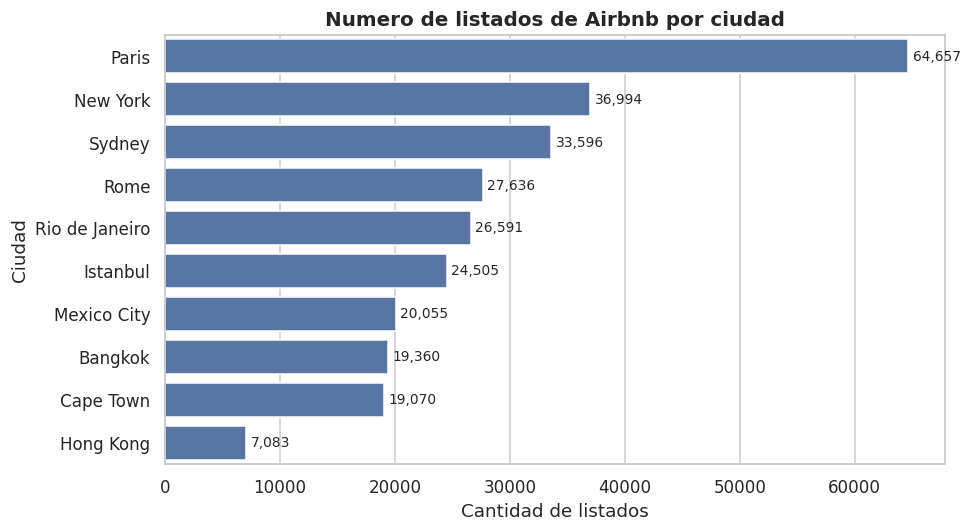

city
Paris             64657
New York          36994
Sydney            33596
Rome              27636
Rio de Janeiro    26591
Istanbul          24505
Mexico City       20055
Bangkok           19360
Cape Town         19070
Hong Kong          7083
Name: count, dtype: int64


In [18]:
conteo_ciudad = df_clean["city"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=conteo_ciudad.values, y=conteo_ciudad.index, color="#4C72B0", ax=ax)
ax.set_title("Numero de listados de Airbnb por ciudad")
ax.set_xlabel("Cantidad de listados")
ax.set_ylabel("Ciudad")
for i, v in enumerate(conteo_ciudad.values):
    ax.text(v + 400, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(conteo_ciudad)

**Interpretación:** la oferta está muy concentrada geográficamente. **París** domina con **64,657 listados** (~23% del total), seguida de Nueva York (36,994) y Sídney (33,596). En el otro extremo, **Hong Kong** apenas tiene **7,083** — casi 9 veces menos que París.

**Recomendación:** cualquier métrica global va a estar dominada por las 3-4 ciudades grandes; para decisiones de negocio o para entrenar un modelo conviene **analizar por ciudad** en vez de promediar todo junto. Hong Kong y Ciudad de México se ven como plazas poco saturadas para expandir oferta.

## Punto 17 — Gráfico de pie: proporción de superhosts

Variable: `host_is_superhost` (True/False). Conteo, comparable entre ciudades.

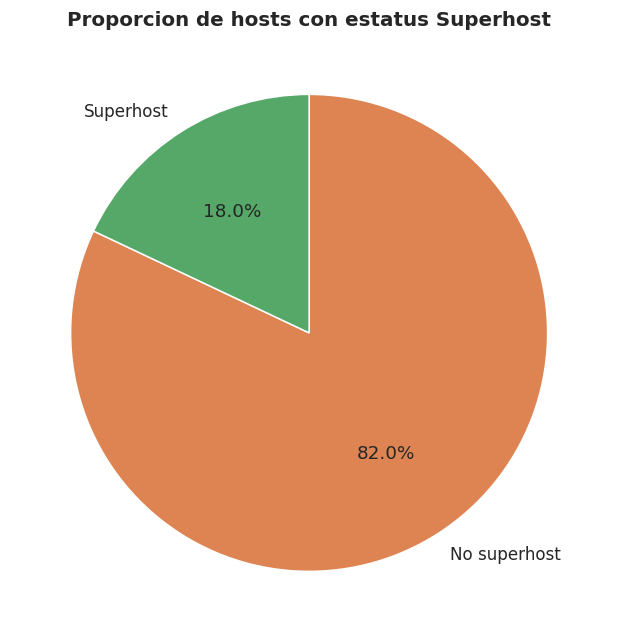

host_is_superhost
False    229294
True      50253
Name: count, dtype: int64


In [19]:
conteo_super = df_clean["host_is_superhost"].value_counts()
etiquetas = ["No superhost" if not k else "Superhost" for k in conteo_super.index]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo_super.values, labels=etiquetas, autopct="%1.1f%%",
       colors=["#DD8452", "#55A868"], startangle=90, counterclock=False,
       wedgeprops={"edgecolor": "white"})
ax.set_title("Proporcion de hosts con estatus Superhost")
plt.tight_layout()
plt.show()

print(conteo_super)

**Interpretación:** solo **18.0%** de los hosts (**50,253**) son **Superhost**, el resto (**82.0%**, 229,294) no. Es selectivo: Airbnb lo da solo a quien cumple umbrales altos de rating, respuesta y cancelaciones.

**Recomendación:** por ser minoritario y ligado a calidad, `host_is_superhost` es una buena variable predictora (de rating, precio o probabilidad de reserva), y del lado de producto sirve como palanca para incentivar a los hosts a mejorar, ya que solo 1 de cada 5 lo logra.

## Punto 18 — Histograma: distribución de `price` (París)

`price` filtrado a París (moneda). Como hay valores extremos (máx = 12,000) que aplastarían el histograma, se acota al **percentil 99 (≤ 600)**; los extremos se ven aparte en el boxplot (Punto 20).

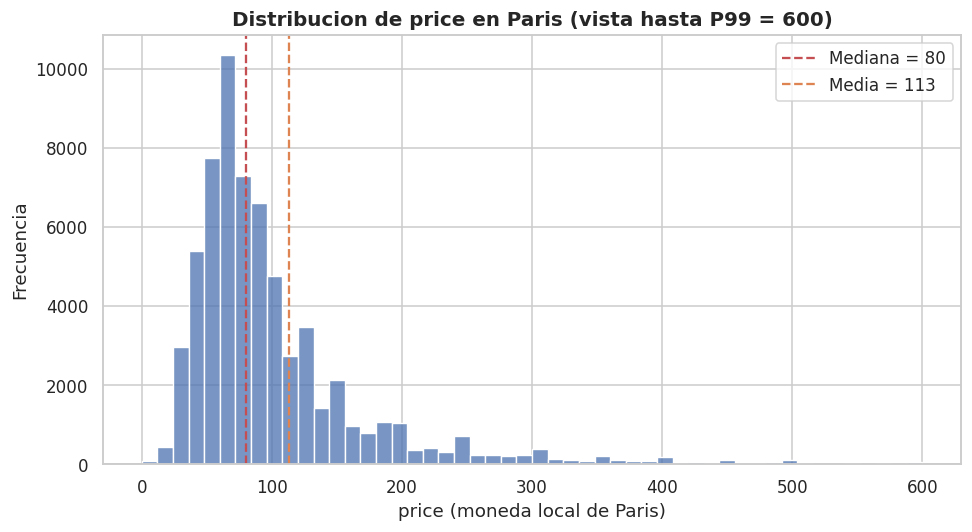

n=64657  media=113.1  mediana=80  asimetria(skew)=29.08  max=12000


In [20]:
price_paris = df_clean.loc[df_clean["city"] == city_top, "price"]
p99 = price_paris.quantile(0.99)
vista = price_paris[price_paris <= p99]

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(vista, bins=50, color="#4C72B0", ax=ax)
ax.axvline(price_paris.median(), color="#C44E52", linestyle="--", label=f"Mediana = {price_paris.median():.0f}")
ax.axvline(price_paris.mean(),  color="#DD8452", linestyle="--", label=f"Media = {price_paris.mean():.0f}")
ax.set_title(f"Distribucion de price en {city_top} (vista hasta P99 = {p99:.0f})")
ax.set_xlabel("price (moneda local de Paris)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

print(f"n={price_paris.shape[0]}  media={price_paris.mean():.1f}  mediana={price_paris.median():.0f}  "
      f"asimetria(skew)={price_paris.skew():.2f}  max={price_paris.max()}")

**Interpretación:** `price` está **muy sesgado a la derecha** (skew ≈ 29). La mayoría de listados tiene precios bajos (**mediana = 80**), pero una cola de propiedades caras sube la **media a 113**. Que la media supere a la mediana confirma el sesgo, no es simétrica ni normal.

**Recomendación:** para "el precio típico" de París usar la **mediana**, no la media. Para un modelo conviene **transformar `price` (log)** para bajar el sesgo, y tratar la cola alta como segmento premium aparte.

## Punto 19 — Scatter plot: `accommodates` vs `price` (París)

Se filtra a París y se recorta al P99 de precio y `accommodates > 0` para que la nube sea legible (los `price==0`/`accommodates==0` son la basura del Punto 11).

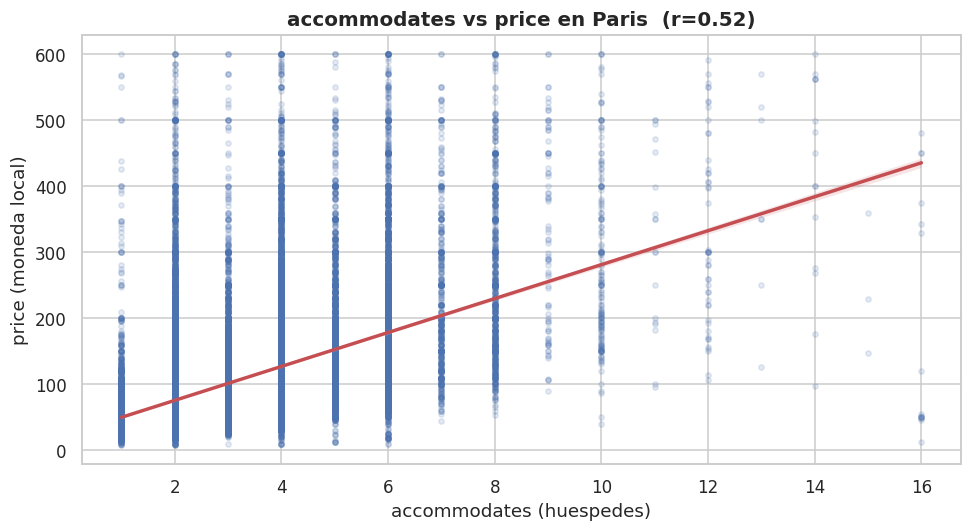

Correlacion Pearson  -> completa: 0.274   |   recortada al P99: 0.520


In [21]:
sub = df_clean[df_clean["city"] == city_top]
sub_v = sub[(sub["accommodates"] > 0) & (sub["price"] > 0) & (sub["price"] <= sub["price"].quantile(0.99))]

r_full = sub["accommodates"].corr(sub["price"])
r_trim = sub_v["accommodates"].corr(sub_v["price"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sub_v["accommodates"], sub_v["price"], alpha=0.15, s=12, color="#4C72B0")
sns.regplot(x="accommodates", y="price", data=sub_v, scatter=False, color="#C44E52", ax=ax)
ax.set_title(f"accommodates vs price en {city_top}  (r={r_trim:.2f})")
ax.set_xlabel("accommodates (huespedes)")
ax.set_ylabel("price (moneda local)")
plt.tight_layout()
plt.show()

print(f"Correlacion Pearson  -> completa: {r_full:.3f}   |   recortada al P99: {r_trim:.3f}")

**Interpretación:** hay **correlación positiva** entre `accommodates` y `price` — a más huéspedes, más precio, esperable. Es **moderada** una vez recortados los extremos (**Pearson r ≈ 0.52**); sin recortar baja a ~0.27 porque los outliers meten ruido. La relación existe pero no es perfecta.

**Recomendación:** `accommodates` sirve pero no alcanza solo; un modelo de precio debería sumar `room_type`, `property_type`, barrio y `bedrooms`. La dispersión también sugiere listados de alta capacidad y precio bajo que podrían estar **infravalorados**.

## Punto 20 — Boxplot: `price` en París y relación con los outliers del Punto 11

Con seaborn, sobre `price` filtrado a París (misma ciudad y variable del Punto 11), para conectar visualmente los outliers con lo calculado por IQR.

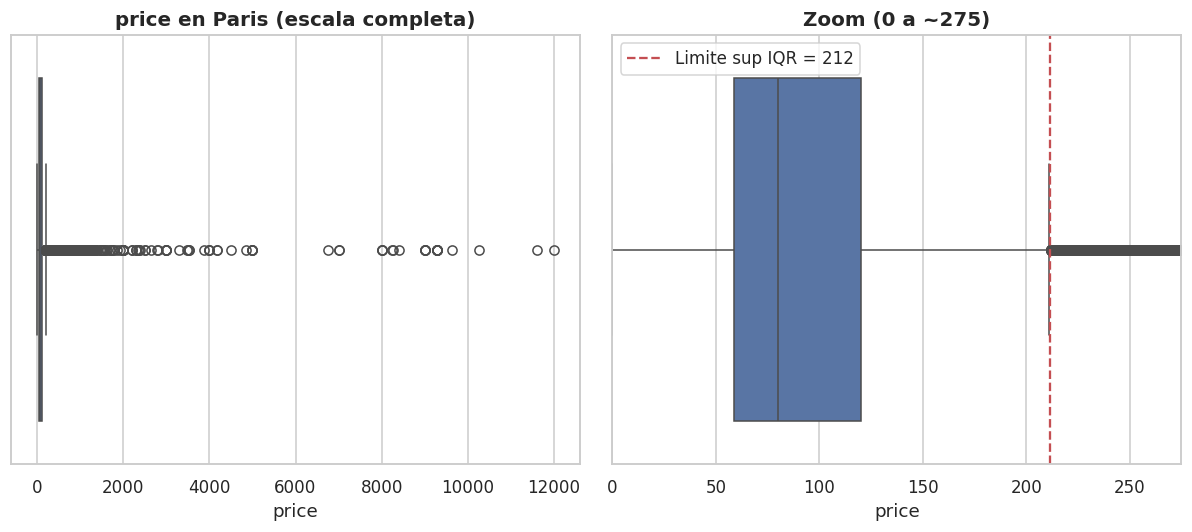

Q1=59  Q3=120  IQR=61  limite_sup=212
Outliers por IQR en Paris: 5,162  (8.0% de los listados)


In [22]:
price_paris = df_clean.loc[df_clean["city"] == city_top, "price"]
Q1, Q3 = price_paris.quantile(0.25), price_paris.quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
n_out = ((price_paris < Q1 - 1.5*IQR) | (price_paris > lim_sup)).sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(x=price_paris, color="#4C72B0", ax=axes[0])
axes[0].set_title(f"price en {city_top} (escala completa)")
axes[0].set_xlabel("price")

sns.boxplot(x=price_paris, color="#4C72B0", ax=axes[1])
axes[1].set_xlim(0, lim_sup * 1.3)
axes[1].axvline(lim_sup, color="#C44E52", linestyle="--", label=f"Limite sup IQR = {lim_sup:.0f}")
axes[1].set_title(f"Zoom (0 a ~{lim_sup*1.3:.0f})")
axes[1].set_xlabel("price")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}  limite_sup={lim_sup:.0f}")
print(f"Outliers por IQR en {city_top}: {n_out:,}  ({n_out/len(price_paris)*100:.1f}% de los listados)")

**Interpretación:** confirma lo del **Punto 11**: la caja (Q1=59, Q3=120) es angosta y pegada a la izquierda, con una nube de puntos que se extiende bien a la derecha. Todo lo que pasa el **límite IQR = 211.5** es outlier: **5,162 listados (8.0%)** de París. No son errores — son propiedades caras reales — pero dominan la cola.

**Recomendación:** no eliminarlos a ciegas (son negocio real), pero sí **acotarlos o transformarlos** (winsorizing/log) y reportar la mediana. Vale la pena tratar el segmento premium (>211.5) como categoría propia.

## Punto 21 — Gráfico de líneas: altas de nuevos hosts por año

El dataset sí tiene variable temporal (`host_since`), así que aplica el gráfico de líneas: cuántos hosts se registraron por año.

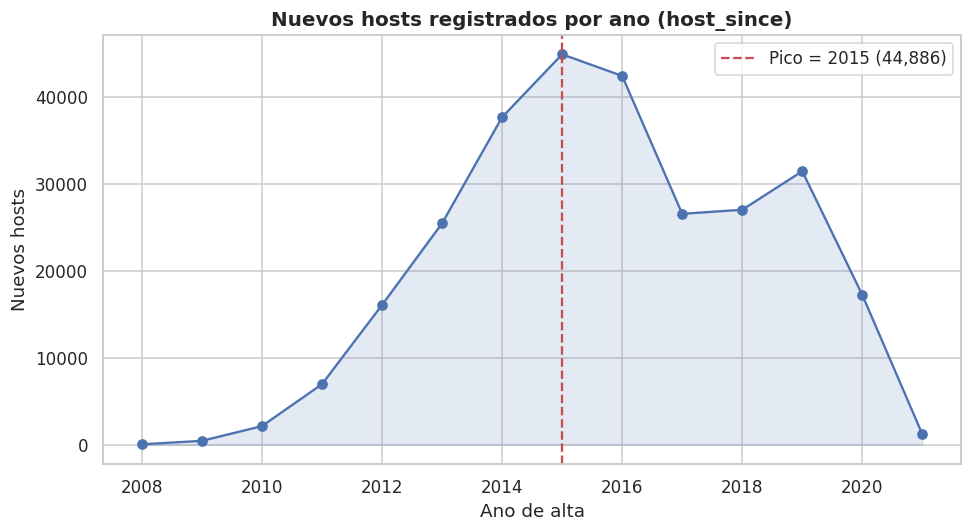

host_since
2008       65
2009      461
2010     2150
2011     6966
2012    16066
2013    25453
2014    37650
2015    44886
2016    42402
2017    26553
2018    27020
2019    31447
2020    17220
2021     1208
Name: count, dtype: int64


In [23]:
host_since = pd.to_datetime(df_clean["host_since"], errors="coerce")
altas_por_ano = host_since.dt.year.value_counts().sort_index()
altas_por_ano = altas_por_ano[altas_por_ano.index <= 2021]   # 2022+ casi sin datos

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(altas_por_ano.index, altas_por_ano.values, marker="o", color="#4C72B0")
ax.fill_between(altas_por_ano.index, altas_por_ano.values, alpha=0.15, color="#4C72B0")
pico = altas_por_ano.idxmax()
ax.axvline(pico, color="#C44E52", linestyle="--", label=f"Pico = {pico} ({altas_por_ano.max():,})")
ax.set_title("Nuevos hosts registrados por ano (host_since)")
ax.set_xlabel("Ano de alta")
ax.set_ylabel("Nuevos hosts")
ax.legend()
plt.tight_layout()
plt.show()

print(altas_por_ano)

**Interpretación:** las altas de hosts **crecen fuerte desde 2010, pican en 2015 (44,886 nuevos hosts)** y después bajan sostenido. La caída de 2020-2021 (17,220 → 1,208) es brusca y coincide con el **COVID-19**, aunque el desplome de 2021 también es porque el dataset se cortó a inicios de ese año (datos incompletos).

**Recomendación:** leer los últimos años con cuidado por el corte de recolección. La curva sugiere un mercado que **maduró tras 2015**: el crecimiento ya no viene de captar hosts nuevos sino de **retener y mejorar** los que hay (de ahí el valor del superhost del Punto 17). `host_since` es buen candidato a variable predictora.

# Fase 5 — Conclusiones

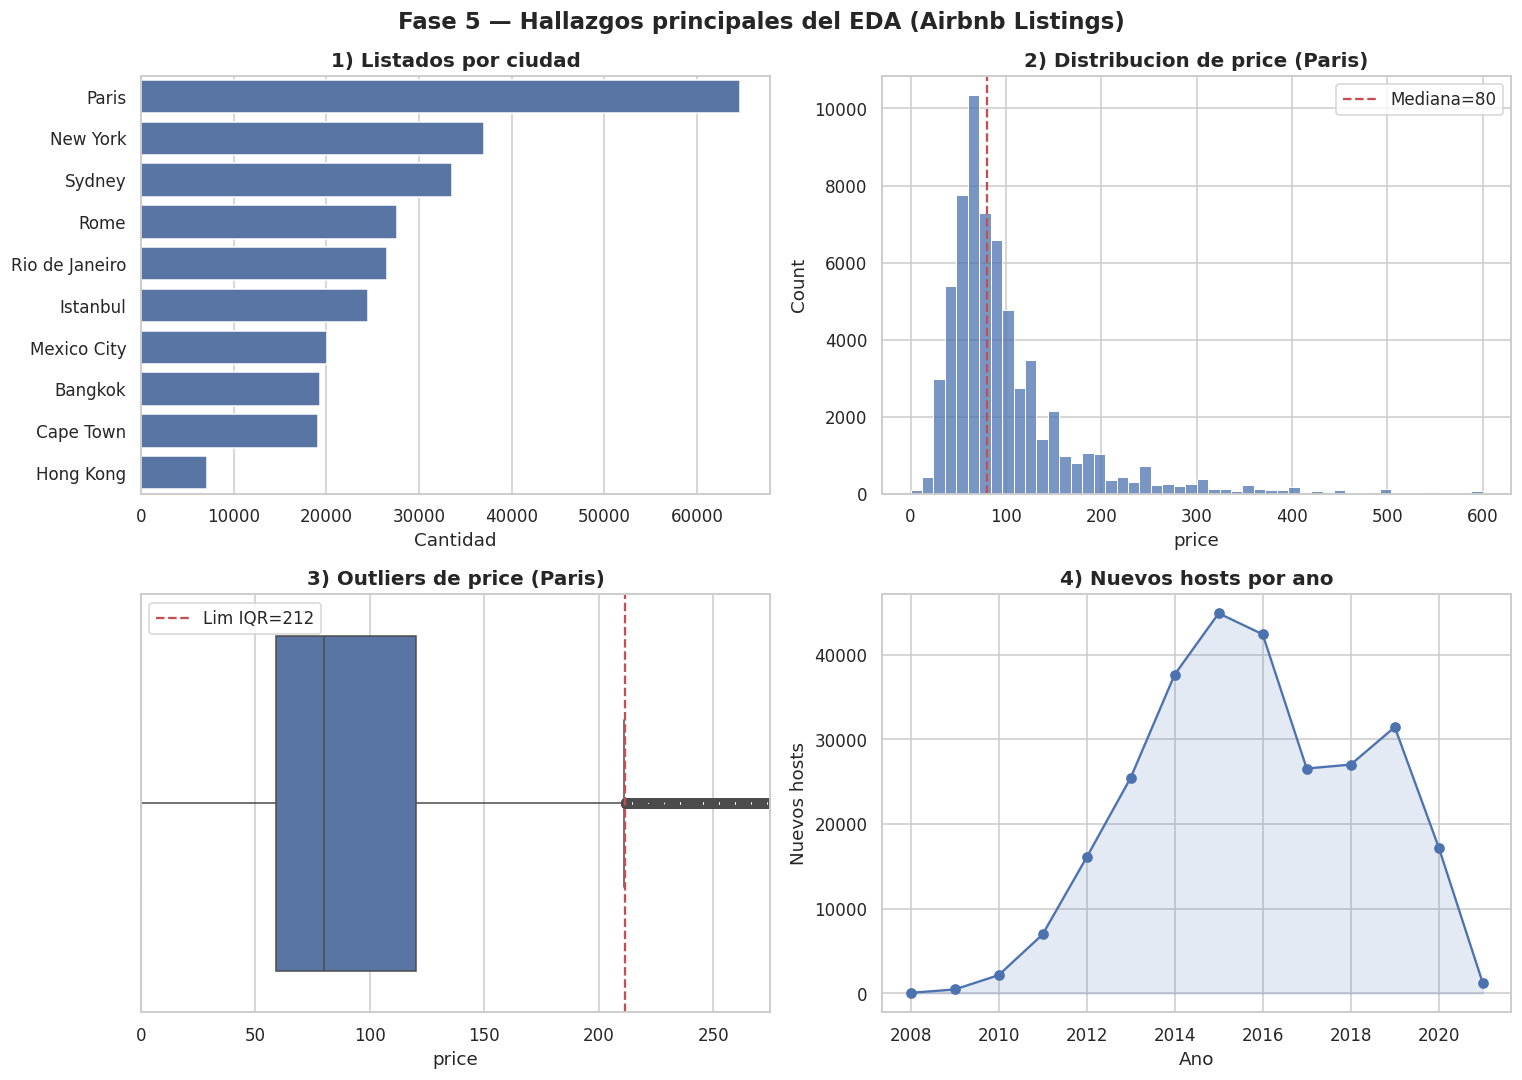

In [24]:
# Subplot (2,2) con los 4 graficos mas relevantes para explicar los hallazgos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) Barras: listados por ciudad
cc = df_clean["city"].value_counts()
sns.barplot(x=cc.values, y=cc.index, color="#4C72B0", ax=axes[0, 0])
axes[0, 0].set_title("1) Listados por ciudad")
axes[0, 0].set_xlabel("Cantidad"); axes[0, 0].set_ylabel("")

# (0,1) Histograma: price en Paris (hasta P99)
pp = df_clean.loc[df_clean["city"] == city_top, "price"]
sns.histplot(pp[pp <= pp.quantile(0.99)], bins=50, color="#4C72B0", ax=axes[0, 1])
axes[0, 1].axvline(pp.median(), color="#C44E52", linestyle="--", label=f"Mediana={pp.median():.0f}")
axes[0, 1].set_title(f"2) Distribucion de price ({city_top})")
axes[0, 1].set_xlabel("price"); axes[0, 1].legend()

# (1,0) Boxplot: price Paris con zoom al rango IQR
Q1, Q3 = pp.quantile(0.25), pp.quantile(0.75); lim = Q3 + 1.5*(Q3-Q1)
sns.boxplot(x=pp, color="#4C72B0", ax=axes[1, 0])
axes[1, 0].set_xlim(0, lim*1.3)
axes[1, 0].axvline(lim, color="#C44E52", linestyle="--", label=f"Lim IQR={lim:.0f}")
axes[1, 0].set_title(f"3) Outliers de price ({city_top})")
axes[1, 0].set_xlabel("price"); axes[1, 0].legend()

# (1,1) Linea: nuevos hosts por ano
hs = pd.to_datetime(df_clean["host_since"], errors="coerce").dt.year.value_counts().sort_index()
hs = hs[hs.index <= 2021]
axes[1, 1].plot(hs.index, hs.values, marker="o", color="#4C72B0")
axes[1, 1].fill_between(hs.index, hs.values, alpha=0.15, color="#4C72B0")
axes[1, 1].set_title("4) Nuevos hosts por ano")
axes[1, 1].set_xlabel("Ano"); axes[1, 1].set_ylabel("Nuevos hosts")

fig.suptitle("Fase 5 — Hallazgos principales del EDA (Airbnb Listings)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusiones generales

**¿Qué aprendí del dataset?** Son **279,547 listados limpios** de Airbnb en 10 ciudades. La oferta está **desbalanceada geográficamente**: París concentra ~23% (64,657) y Hong Kong solo 7,083. El precio es lo más delicado — está en **moneda local por ciudad**, así que solo se puede analizar dentro de cada una; su distribución está **muy sesgada a la derecha** (mediana 80 vs media 113 en París), con ~8% de outliers por IQR. En el tiempo, las altas de hosts **crecieron hasta 2015 y después cayeron**, con un desplome en 2020-2021 por COVID y por el corte de recolección.

**¿Qué variables parecen más relevantes?** Para el precio: `city` (define moneda y nivel base), `room_type`/`property_type`, `accommodates` (r≈0.52 en París) y `bedrooms`. Para calidad: `host_is_superhost` (solo 18%) y `review_scores_rating`. `host_since` aporta la señal temporal.

**¿Qué limpieza hizo falta?** Encoding roto (mojibake en nombres de barrios), nulos estructurales dejados sin imputar (`district`, `review_scores_*`, `host_response_*`) vs. aleatorios imputados (`bedrooms` → mediana), ~165 filas eliminadas por metadata de host incompleta, y basura no estadística identificada (`price==0`, `accommodates==0`, `minimum_nights==9999`). Sin esto, medias, conteos y correlaciones habrían salido distorsionados.

**¿Qué queda abierto para un futuro modelo?** (1) Predecir `price` por ciudad (o convirtiendo a moneda común) usando capacidad, tipo, barrio y atributos del host, con `price` en log por el sesgo. (2) Predecir `host_is_superhost` o `review_scores_rating` desde el comportamiento del host. (3) ¿Los `amenities` aportan si se pasan a dummies? (4) ¿Cómo tratar la cola premium — winsorizing, segmentación, modelo aparte? El subplot (2,2) de arriba resume los cuatro hallazgos que sostienen estas conclusiones.